#### Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
import amrex.space3d as amr

#### Useful functions/classes

In [18]:
### Takes a box and splits it into cubes (blocks) of a specified dimension. Returns
### a list of torch tensors, each representing one block of the volume. If block_dim
### does not divide equally into the volume dimensions, creates blocks that extend past the
### dimensions of the volume, and populates the coordinates outside the volume with a chosen 
### junk, which is an input to the function
def to_blocks(box, block_dim, junk):
    
    xdim = box.shape[0]
    ydim = box.shape[1]
    zdim = box.shape[2]

    x_steps = int(xdim // block_dim)
    if xdim % block_dim != 0:
        x_steps += 1
    if xdim < block_dim:
        x_steps = 1
    y_steps = int(ydim / block_dim)
    if ydim % block_dim != 0:
        y_steps += 1
    if ydim < block_dim:
        y_steps = 1
    z_steps = int(zdim / block_dim)
    if zdim % block_dim != 0:
        z_steps += 1
    if zdim < block_dim:
        z_steps = 1
    num_blocks = int(x_steps * y_steps * z_steps)

    blocks = []

    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):

                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)

                block = np.empty((block_dim, block_dim, block_dim))

                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):

                            if (x_lo + x) >= xdim:
                                block[x][y][z] = junk
                            elif (y_lo + y) >= ydim:
                                block[x][y][z] = junk
                            elif (z_lo + z) >= zdim:
                                block[x][y][z] = junk
                            else:
                                block[x][y][z] = box[x_lo + x][y_lo + y][z_lo + z]
                
                blocks.append(block)

    return blocks


### Reads binary files in input_dir up to a maximum time step (max), and stores them in a nested
### list of format all_data[time_step][block_idx][x][y][z]
def process_data(input_dir, min_file, max_file, level, component):
    
    boxes = []
    locations = []
    dimensions = []
    box_counts = []

    print("Processing data...")
    for t in tqdm(range(min_file, max_file)): # iterate over each time step
        filename = input_dir + str(t) + "-wholeNewFormat-" + str(component) + "-" + str(level) + ".raw"

        box_count = 0
        
        with open(filename, "rb") as file:
            while True:
                test = file.read(4)
                if len(test) < 4:
                    break
                x = int(struct.unpack('<f', test)[0])
                y = int(struct.unpack('<f', file.read(4))[0])
                z = int(struct.unpack('<f', file.read(4))[0])
                locations.append((x, y, z))

                xdim = int(struct.unpack('<f', file.read(4))[0])
                ydim = int(struct.unpack('<f', file.read(4))[0])
                zdim = int(struct.unpack('<f', file.read(4))[0])
                dimensions.append((xdim, ydim, zdim))

                box = np.empty((xdim, ydim, zdim))
                for k in range(zdim):
                    for j in range(ydim):
                        for i in range(xdim):
                            box[i][j][k] = struct.unpack('<f', file.read(4))[0]
                boxes.append(box)
                box_count += 1
        box_counts.append(box_count)

    print(box_counts)
    return boxes, locations, dimensions, box_counts


### Assembles processed data into samples that can be used to train an autoencoder. Returns
### torch tensors with dimensions num_samples x 1 x block_dim x block_dim x block_dim; note
### that input and output are the same when training an autoencoder, so returns two instances
### of inputs
def create_samples(boxes, block_dim, junk):

    print("Creating samples...")
    
    # Check if block_dim is a power of 2 (necessary for convolutional autoencoder)
    if not math.log2(block_dim).is_integer():
        print("Invalid block_dim! Dimension must be a power of 2.")
        return
    
    inputs = []
    for i in tqdm(range(len(boxes))):
        box = boxes[i]
        blocks = to_blocks(box, block_dim, junk)
        for l in range(len(blocks)):
            input = blocks[l]
            inputs.append(input)

    inputs = np.array(inputs)
    inputs = torch.tensor(inputs, dtype=torch.float32)
    inputs = inputs[:, None, :, :, :]
    return inputs, inputs
    

class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        self.X_full = X_full
        self.y_full = y_full

    def __len__(self):
        return len(self.X_full)

    def __getitem__(self, idx):
        input = self.X_full[idx]
        output = self.y_full[idx]
        return input, output

#### Hyperparameters

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
batch_size = 256
level = 0
if level == 0:
    epochs = 1000;
else:
    epochs = 100;
component = 6

Running on cuda


In [25]:
dir = "wholeVolumesNewFormat-" + str(component) + "-" + str(level) + "/"
print("Retrieving data from directory", dir)
boxes, locations, dimensions, num_boxes = process_data(dir, 74, 84, 0, 6)
x, y = create_samples(boxes, 16, 0)
print(x.shape)
print(y.shape)

# Scale the data to be between 0 and 1
xmin = x.min()
xmax = x.max()
ymin = y.min()
ymax = y.max()
xnormal = (x - xmin) / (xmax - xmin)
ynormal = (y - ymin) / (ymax - ymin)

# Initialize the dataset, and create data loader
dataset = CombustionData(xnormal, ynormal)
train_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

Retrieving data from directory wholeVolumesNewFormat-6-0/
Processing data...


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:09<00:00,  1.08it/s]


[576, 576, 576, 576, 576, 576, 576, 576, 288, 288]
Creating samples...


100%|██████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:12<00:00, 408.55it/s]


torch.Size([5760, 1, 16, 16, 16])
torch.Size([5760, 1, 16, 16, 16])


#### Model initialization

In [26]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 128, kernel_size=3, stride=2, padding=1), # Output: 128 channels, block_dim/2
            nn.ReLU(),
            nn.Conv3d(128, 256, kernel_size=3, stride=2, padding=1), # Output: 256 channels, block_dim/4
            nn.ReLU(),
            nn.Conv3d(256, 512, kernel_size=3, stride=2, padding=1), # Output: 512 channels, block_dim/8
            nn.ReLU(),
            nn.Conv3d(512, 1024, kernel_size=3, stride=2, padding=1), # Output: 1024 channels, block_dim/16
            #nn.ReLU(),
            #nn.Conv3d(512, 1024, kernel_size=3, stride=2, padding=1) # Output: 1024 channels, block_dim/32
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(1024, 512, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 512 channels, block_dim/16
            nn.ReLU(),
            nn.ConvTranspose3d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 256 channels, block_dim/8
            nn.ReLU(),
            nn.ConvTranspose3d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 128 channels, block_dim/4
            nn.ReLU(),
            nn.ConvTranspose3d(128, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 1 channel, block_dim/2
            #nn.ReLU(),
            #nn.ConvTranspose3d(64, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 1 channel, block_dim
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def decode(self, x):
        return self.decoder(x)

model = ConvAutoencoder()

#### Train model

In [32]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_hist = []

for epoch in range(epochs):
    losses = []
    for sample in train_loader:
        # Get the inputs
        inputs = sample[0]

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        _, outputs = model(inputs)

        # Compute the loss
        loss = criterion(outputs, inputs)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    epoch_loss = np.mean(losses)
    train_hist.append(epoch_loss)
    if epoch_loss < 0.00008:
        break
    
    if epochs == 100:
        print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {epoch_loss:.8f}")
    else:
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {epoch_loss:.8f}")

print("Completed", epoch, "epochs of training, ending with a loss of", epoch_loss)

Epoch 10/1000: Training Loss = 0.00088224
Epoch 20/1000: Training Loss = 0.00070209
Epoch 30/1000: Training Loss = 0.00061833
Epoch 40/1000: Training Loss = 0.00050027
Epoch 50/1000: Training Loss = 0.00045463
Epoch 60/1000: Training Loss = 0.00043301
Epoch 70/1000: Training Loss = 0.00043700
Epoch 80/1000: Training Loss = 0.00042502
Epoch 90/1000: Training Loss = 0.00031518
Epoch 100/1000: Training Loss = 0.00023846
Epoch 110/1000: Training Loss = 0.00025812
Epoch 120/1000: Training Loss = 0.00022020
Epoch 130/1000: Training Loss = 0.00019184
Epoch 140/1000: Training Loss = 0.00019443
Epoch 150/1000: Training Loss = 0.00016914
Epoch 160/1000: Training Loss = 0.00016319
Epoch 170/1000: Training Loss = 0.00018139
Epoch 180/1000: Training Loss = 0.00016457
Epoch 190/1000: Training Loss = 0.00014194
Epoch 200/1000: Training Loss = 0.00014320
Epoch 210/1000: Training Loss = 0.00018044
Epoch 220/1000: Training Loss = 0.00015329
Epoch 230/1000: Training Loss = 0.00011554
Epoch 240/1000: Trai

#### Plot loss

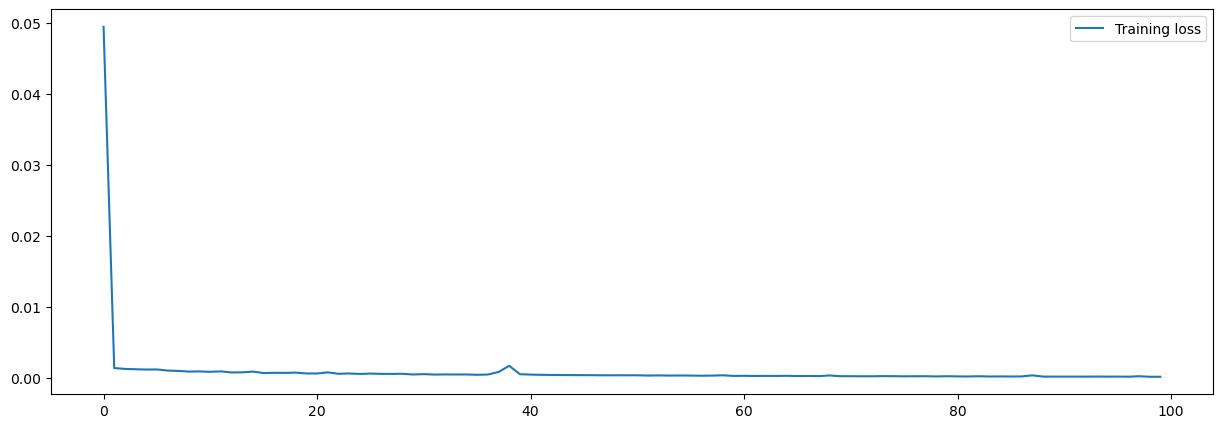

In [8]:
plt.figure(figsize=(15,5))
plt.plot(range(100), train_hist, label='Training loss')
plt.legend()

#### Calc size of model

In [33]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 141.787MB


#### Save model

In [34]:
model_path = "testModels/model-" + str(6) + "-level" + str(level) + ".pt"
torch.save(model.state_dict(), model_path)

#### Load model

In [5]:
model.load_state_dict(torch.load("testModels/model1-level1.pt"))

/tmp/ipykernel_3448982/2144423155.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("testModels/model1-level1.pt"))


<All keys matched successfully>

#### Functions to encode and decode data

In [36]:
def write_to_bin(volume, path, out_file):
    filename = path + out_file
    with open(filename, "wb") as file:
        volume.tofile(file)


def encode(encoder, input_dir, min_file, max_file, level, component, block_dim, junk):

    boxes, locations, dimensions, box_counts = process_data(input_dir, min_file, max_file, level, component)
    inputs, _ = create_samples(boxes, block_dim, junk)

    print("Inputs formatted successfully. Beginning encoding...")
    
    # Scale the data to be between 0 and 1
    input_min = inputs.min()
    input_max = inputs.max()
    input_normal = (inputs - input_min) / (input_max - input_min)

    encoded, _ = encoder(input_normal)
    print("Encoding complete. Writing files...")

    dir = "encoded-" + str(level) + "/"
    # Note: use transpose to get a 3 row X num_boxes column to make reading easier in c++
    write_to_bin(np.array(box_counts, dtype="float32"), dir, "boxCounts.raw")
    write_to_bin(np.array(locations, dtype="float32").T, dir, "locations.raw")
    write_to_bin(np.array(dimensions, dtype="float32").T, dir, "dimensions.raw")
    for b in tqdm(range(len(encoded))):
        box = encoded[b]
        box = box.cpu().detach().squeeze()
        filename = "box-" + str(b) + ".raw"
        write_to_bin(np.array(box, dtype="float32"), dir, filename)

    print("Successfully wrote files.")
    return encoded, locations, dimensions, box_counts, input_min, input_max




def decode(decoder, coded, inmin, inmax, locations, dimensions, block_dim):

    num_boxes = len(locations)
    block_idx = 0

    regenerated = []

    print("Beginning decoding...")
    for i in tqdm(range(num_boxes)):

        dims = dimensions[i]
        xdim, ydim, zdim = dims[0], dims[1], dims[2]

        generated = np.empty((xdim, ydim, zdim))
        
        x_steps = int(xdim // block_dim)
        if xdim % block_dim != 0:
            x_steps += 1
        y_steps = int(ydim / block_dim)
        if ydim % block_dim != 0:
            y_steps += 1
        z_steps = int(zdim / block_dim)
        if zdim % block_dim != 0:
            z_steps += 1

        for k in range(z_steps):
            for j in range(y_steps):
                for i in range(x_steps):

                    x_lo = int(i * block_dim)
                    y_lo = int(j * block_dim)
                    z_lo = int(k * block_dim)

                    block = coded[block_idx]
                    decoded = decoder.decode(block)
                    decoded = decoded * (inmax - inmin) + inmin
                    decoded = decoded.cpu().detach().squeeze()

                    for z in range(block_dim):
                        for y in range(block_dim):
                            for x in range(block_dim):
                                if (x_lo + x) < xdim and (y_lo + y) < ydim and (z_lo + z) < zdim:
                                    generated[x_lo + x][y_lo + y][z_lo + z] = decoded[x][y][z]

                    block_idx += 1

        regenerated.append(generated)

    print("Decoding completed successfully.")

    return regenerated, locations, dimensions


def calc_avg_rmse(actuals, regens):

    rmses = []
    
    for s in range(len(actuals)):

        actual = actuals[s]
        pred = regens[s]
        
        xdim = actual.shape[0]
        ydim = actual.shape[1]
        zdim = actual.shape[2]

        sum = 0
        
        for k in range(zdim):
            for j in range(ydim):
                for i in range(xdim):
                    sq = (actual[i][j][k] - pred[i][j][k])**2
                    sum += sq

        rmse = (sum / (xdim * ydim * zdim))**0.5
        rmses.append(rmse)

    rmses = np.array(rmses)
    return rmses.mean()

#### Encode, decode, and check RMSE

In [40]:
dir = "wholeVolumesNewFormat-" + str(component) + "-" + str(level) + "/"
encoded, locations, dimensions, box_counts, input_min, input_max = encode(model, dir, 74, 84, 0, 6, 16, 0)
regenerated, locations, dimensions = decode(model, encoded, input_min, input_max, locations, dimensions, 16)
rmse = calc_avg_rmse(boxes, regenerated)
print(rmse)

Processing data...


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:09<00:00,  1.08it/s]


[576, 576, 576, 576, 576, 576, 576, 576, 288, 288]
Creating samples...


100%|██████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:12<00:00, 407.03it/s]


Inputs formatted successfully. Beginning encoding...
Encoding complete. Writing files...


  0%|                                                                                          | 0/5760 [00:00<?, ?it/s]/tmp/ipykernel_3448982/3237294895.py:31: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  write_to_bin(np.array(box, dtype="float32"), dir, filename)
100%|█████████████████████████████████████████████████████████████████████████████| 5760/5760 [00:01<00:00, 4036.32it/s]


Successfully wrote files.
Beginning decoding...


100%|███████████████████████████████████████████████████████████████████████████████| 5184/5184 [04:24<00:00, 19.62it/s]


Decoding completed successfully.
16.150922302973996


#### Write decoded data to files

In [42]:
def write_decoded(regenerated):

    for i in tqdm(range(len(regenerated))):
        box = regenerated[i]
        box = np.array(box, dtype="float32")
        path = "decoded-" + str(level) + "/"
        filename = "decodedBox-" + str(i) + ".raw"
        write_to_bin(box, path, filename)


write_decoded(regenerated)

100%|█████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:01<00:00, 4818.92it/s]
